# Learning a Hamiltonian from classical shadows

Jasper Sands · `shadow_learning` 0.4

1. Pauli shadows of a Bell state and the unbiased estimator
2. Error against the number of snapshots
3. Choosing bases deliberately (Huang–Kueng–Preskill derandomisation)
4. Readout errors, and why asymmetric ones need a per-shot correction
5. Recovering (J, h) from a thermal state, including fully degenerate spectra, and which directions the data can see
6. Tracking a drifting coupling with a Kalman filter
7. Matchgate shadows: one- and two-body density matrices, and 24 modes without a 2²⁴ state
8. Process tomography constrained to physical channels

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import cirq
from shadow_learning import (
    measure_random_pauli_shadows, sample_shadows_from_density_matrix, gibbs_state,
    estimate_many_observables, estimate_pauli_string_expectation, DerandomizedShadowSelector, hits_per_observable,
    ReadoutErrorModel, DifferentiableHamiltonianLearner, StreamingKalmanHamiltonianTracker,
    FermionicMatchgateShadows, slater_state, ShadowProcessTomographer, __version__,
)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
print("shadow_learning", __version__, "| cirq", cirq.__version__)

shadow_learning 0.4.0 | cirq 1.7.0


## 1. Pauli shadows of a Bell state

Each snapshot measures every qubit in a uniformly random Pauli basis. For a weight-$k$ Pauli string the unbiased single-snapshot estimator is $\prod_i 3(-1)^{b_i}\delta(W_i,P_i)$.

In [2]:
q = cirq.LineQubit.range(2)
bell = cirq.Circuit(cirq.H(q[0]), cirq.CNOT(q[0], q[1]))
snaps = measure_random_pauli_shadows(bell, n_qubits=2, n_snapshots=3000, seed=1)
print("first snapshots:", snaps[:3])
print(estimate_many_observables(snaps, ["ZZ", "XX", "YY", "ZI"]), "   (truth 1, 1, −1, 0)")

first snapshots: [ShadowSnapshot(bases=('Y', 'Y'), bits=(1, 0)), ShadowSnapshot(bases=('X', 'X'), bits=(1, 1)), ShadowSnapshot(bases=('X', 'X'), bits=(0, 0))]
{'ZZ': 0.984, 'XX': 0.948, 'YY': -1.014, 'ZI': -0.061}    (truth 1, 1, −1, 0)


## 2. Error versus snapshot budget

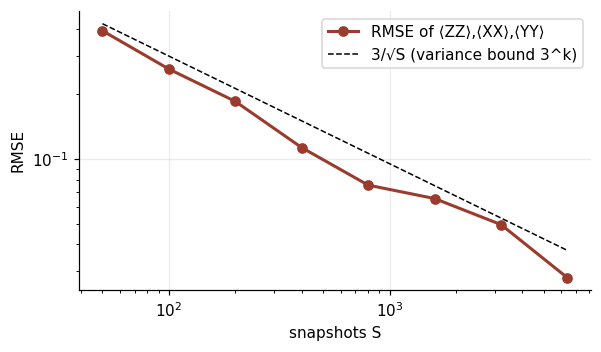

In [3]:
rho_bell = np.outer([1, 0, 0, 1], [1, 0, 0, 1]) / 2
budgets = [50, 100, 200, 400, 800, 1600, 3200, 6400]
errs = []
for S in budgets:
    trial = []
    for t in range(20):
        e = estimate_many_observables(sample_shadows_from_density_matrix(rho_bell, S, np.random.default_rng(1000 * S + t)), ["ZZ", "XX", "YY"])
        trial.append(np.sqrt(np.mean([(e["ZZ"] - 1) ** 2, (e["XX"] - 1) ** 2, (e["YY"] + 1) ** 2])))
    errs.append(np.mean(trial))
fig, ax = plt.subplots(figsize=(6, 3.3))
ax.loglog(budgets, errs, "o-", lw=2, color="#9a3b2e", label="RMSE of ⟨ZZ⟩,⟨XX⟩,⟨YY⟩")
ax.loglog(budgets, 3 / np.sqrt(budgets), "--", color="k", lw=1, label="3/√S (variance bound 3^k)")
ax.set_xlabel("snapshots S"); ax.set_ylabel("RMSE"); ax.legend(); plt.show()

## 3. Derandomised shadows

Algorithm 1 of Huang, Kueng & Preskill (2021) picks each shot's bases greedily to minimise the expected confidence bound $\sum_o e^{-\varepsilon^2 h_o/2}$. For a fixed observable set this beats random bases at equal budget.

In [4]:
learner3 = DifferentiableHamiltonianLearner(n_qubits=3, beta=1.0)
J3 = np.array([[0, 0.7, 0], [0.7, 0, -0.4], [0, -0.4, 0]]); h3 = np.array([0.2, 0.0, -0.3])
rho3 = gibbs_state(learner3.build_hamiltonian_matrix(J3, h3), 1.0)
targets = ["XXI", "YYI", "ZZI", "IXX", "IYY", "IZZ"]
truth = {P: float(np.real(np.trace(learner3.pauli_matrix(P) @ rho3))) for P in targets}
bases = DerandomizedShadowSelector(targets, n_qubits=3).select_measurement_bases(300)
print("first derandomised bases:", bases[:6])
print("coverage per target over 300 shots:", hits_per_observable(bases, targets))
rr, rd = [], []
for t in range(20):
    rng = np.random.default_rng(t)
    er = estimate_many_observables(sample_shadows_from_density_matrix(rho3, 300, rng), targets)
    ed = estimate_many_observables(sample_shadows_from_density_matrix(rho3, 300, rng, bases=bases), targets, derandomized=True)
    rr.append(np.sqrt(np.mean([(er[P] - truth[P]) ** 2 for P in targets]))); rd.append(np.sqrt(np.mean([(ed[P] - truth[P]) ** 2 for P in targets])))
print(f"RMSE random {np.mean(rr):.4f} | derandomised {np.mean(rd):.4f} | gain ×{np.mean(rr)/np.mean(rd):.2f}")

first derandomised bases: [('X', 'X', 'X'), ('Y', 'Y', 'Y'), ('Z', 'Z', 'Z'), ('X', 'X', 'X'), ('Y', 'Y', 'Y'), ('Z', 'Z', 'Z')]
coverage per target over 300 shots: {'XXI': 100, 'YYI': 100, 'ZZI': 100, 'IXX': 100, 'IYY': 100, 'IZZ': 100}
RMSE random 0.1638 | derandomised 0.0810 | gain ×2.02


## 4. Readout errors

With $p(1|0)=p_{01}$ and $p(0|1)=p_{10}$ the measured $\langle Z\rangle$ becomes $(1-p_{01}-p_{10})\langle Z\rangle + (p_{10}-p_{01})$: a scale *and* a shift. Dividing by $(1-p_{01}-p_{10})^k$ (v0.2) only fixes the scale. Replacing $(-1)^b$ by $g(b) = ((M^\top)^{-1}(1,-1))_b$ is exact.

In [5]:
plus = np.array([1, 1]) / np.sqrt(2); rho_p = np.outer(plus, plus)
model = ReadoutErrorModel(p01=0.02, p10=0.10)
snaps = sample_shadows_from_density_matrix(rho_p, 8000, np.random.default_rng(3), readout_error=model)
raw = estimate_pauli_string_expectation(snaps, "X")
print(f"raw <X> = {raw:.3f}   (prediction {(1-0.12)*1 + 0.08:.3f})")
print(f"symmetric rule <X>/(1-p01-p10) = {raw / model.readout_fidelity:.3f}   ← overshoots")
print(f"single-shot inversion            = {estimate_pauli_string_expectation(snaps, 'X', readout_model=model):.3f}   (truth 1)")
print("corrected eigenvalues g(0), g(1):", model.corrected_eigenvalue(0), model.corrected_eigenvalue(1))

raw <X> = 0.962   (prediction 0.960)
symmetric rule <X>/(1-p01-p10) = 1.093   ← overshoots
single-shot inversion            = 1.002   (truth 1)
corrected eigenvalues g(0), g(1): 1.0454545454545454 -1.227272727272727


## 5. Learning $(J, h)$ from Gibbs-state shadows

$H = \sum_{i<j} J_{ij}\,\vec\sigma_i\cdot\vec\sigma_j + \sum_i h_i Z_i$. The loss $\sum_o(\langle o\rangle_{\rho_\beta(J,h)} - \hat o)^2$ is minimised with exact gradients: the Fréchet derivative of $e^{-\beta H}$, written with divided differences that have a finite limit when two levels coincide. The Jacobian's singular values show which parameter combinations the data can resolve.

β = 0.6: J01 +0.509 (0.500)   h [ 0.366 -0.282] ([ 0.4  -0.25])   analytic-lbfgs, 13 it, 0.09 s
        singular values [1.345 0.696 0.362]  condition 3.7  least identifiable direction (J01, h0, h1) = [-0.03 -0.72 -0.69]
β = 1.5: J01 +0.495 (0.500)   h [ 0.354 -0.295] ([ 0.4  -0.25])   analytic-lbfgs, 23 it, 0.03 s
        singular values [1.792 0.929 0.2  ]  condition 9.0  least identifiable direction (J01, h0, h1) = [0.07 0.75 0.66]
At β = 1.5 the state is ~singlet, which screens a uniform field: h0 + h1 is poorly determined while h0 − h1 and J are fine.


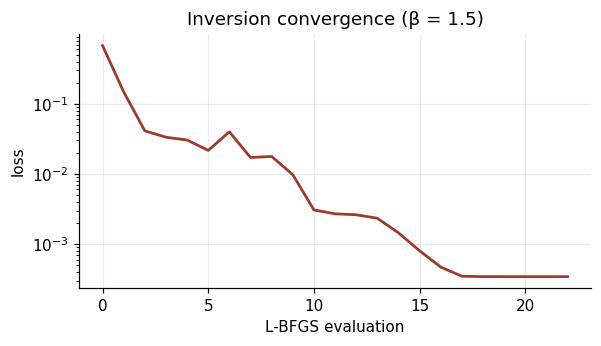

In [6]:
for beta in (0.6, 1.5):
    learner = DifferentiableHamiltonianLearner(n_qubits=2, beta=beta, seed=1)
    J = np.array([[0, 0.5], [0.5, 0]]); h = np.array([0.4, -0.25])
    rho = gibbs_state(learner.build_hamiltonian_matrix(J, h), beta)
    snaps = sample_shadows_from_density_matrix(rho, 8000, np.random.default_rng(5))
    t0 = time.time(); res = learner.learn_from_shadows(snaps, true_j_matrix=J, true_h_vector=h); dt = time.time() - t0
    ident = learner.identifiability(J, h)
    print(f"β = {beta}: J01 {res.recovered_j_matrix[0,1]:+.3f} (0.500)   h {np.round(res.recovered_h_vector, 3)} ({h})   "
          f"{res.method}, {res.iterations} it, {dt:.2f} s")
    print(f"        singular values {np.round(ident['singular_values'], 3)}  condition {ident['condition_number']:.1f}  "
          f"least identifiable direction (J01, h0, h1) = {np.round(ident['least_identifiable'], 2)}")
print("At β = 1.5 the state is ~singlet, which screens a uniform field: h0 + h1 is poorly determined while h0 − h1 and J are fine.")
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(res.loss_history, lw=1.8, color="#9a3b2e"); ax.set_xlabel("L-BFGS evaluation"); ax.set_ylabel("loss"); ax.set_title("Inversion convergence (β = 1.5)"); plt.show()

An SU(2)-symmetric chain ($h = 0$) has exactly degenerate multiplets. Differentiating an eigendecomposition returns NaN there, because the eigenvector derivative divides by $w_i - w_j$. The divided-difference formula does not, and the optional JAX backend (autodiff through `expm`) agrees with it.

In [7]:
from shadow_learning import differentiable_inversion as di
for n in (3, 4):
    L = DifferentiableHamiltonianLearner(n_qubits=n, beta=1.0, seed=0)
    J = np.diag([0.5] * (n - 1), 1); J = J + J.T; h = np.zeros(n)
    w = np.linalg.eigvalsh(L.build_hamiltonian_matrix(J, h))
    t = L.compute_thermal_observables(J, h)
    g = L.loss_and_grad(L.pack(J, h) + 0.05, t)[1]
    line = f"n = {n}: {len(w) - len(np.unique(np.round(w, 9)))} repeated levels, gradient finite: {np.all(np.isfinite(g))}"
    if di.HAS_JAX:
        line += f", |analytic − JAX| = {np.abs(g - L.loss_and_grad(L.pack(J, h) + 0.05, t, backend='jax')[1]).max():.1e}"
    res_n = L.learn_from_expectations(t, J, h)
    print(line + f", recovery error {res_n.frobenius_error:.1e}")

n = 3: 5 repeated levels, gradient finite: True, |analytic − JAX| = 6.9e-16, recovery error 3.3e-08
n = 4: 10 repeated levels, gradient finite: True, |analytic − JAX| = 5.3e-15, recovery error 8.7e-08


## 6. Tracking with a Kalman filter

Each snapshot yields one ±1 outcome for every model observable compatible with its bases, and those outcomes are correlated. The filter makes one joint update per snapshot using their exact covariance in the current Gibbs state, and updates the covariance in Joseph form so it stays symmetric and positive. It is a Gaussian approximation to a discrete measurement, so the reported uncertainty is checked against the actual error below.

estimate at 1400: 0.340  at 3000: 0.814
mean (error/σ)² over 18 parameter estimates: 0.74  (1 for a calibrated filter)


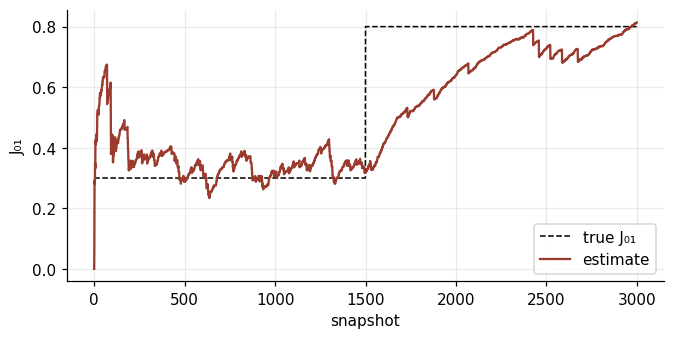

In [8]:
tracker = StreamingKalmanHamiltonianTracker(n_qubits=2, beta=1.5, process_noise_std=0.005, seed=0)
rng = np.random.default_rng(7); est, truth_j = [], []
for k in range(3000):
    jv = 0.3 if k < 1500 else 0.8
    if k % 250 == 0:
        rho_k = gibbs_state(tracker.learner.build_hamiltonian_matrix(np.array([[0, jv], [jv, 0]]), np.array([0.2, -0.15])), 1.5)
    tracker.process_snapshot(sample_shadows_from_density_matrix(rho_k, 1, rng)[0])
    est.append(tracker.x[0]); truth_j.append(jv)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(truth_j, color="k", lw=1, ls="--", label="true J₀₁"); ax.plot(est, color="#9a3b2e", lw=1.5, label="estimate")
ax.set_xlabel("snapshot"); ax.set_ylabel("J₀₁"); ax.legend(); plt.show()
print(f"estimate at 1400: {est[1399]:.3f}  at 3000: {est[-1]:.3f}")

# calibration of the reported standard deviations on a static model
z2 = []
for seed in range(6):
    tr = StreamingKalmanHamiltonianTracker(n_qubits=2, beta=0.6, process_noise_std=0.0, seed=seed)
    Jt, ht = np.array([[0, 0.5], [0.5, 0]]), np.array([0.3, -0.2])
    rho_t = gibbs_state(tr.learner.build_hamiltonian_matrix(Jt, ht), 0.6)
    for sn in sample_shadows_from_density_matrix(rho_t, 3000, np.random.default_rng(seed)):
        tr.process_snapshot(sn)
    e = tr.estimate(); z2.extend(((e["params"] - tr.learner.pack(Jt, ht)) / e["std"]) ** 2)
print(f"mean (error/σ)² over {len(z2)} parameter estimates: {np.mean(z2):.2f}  (1 for a calibrated filter)")

## 7. Matchgate shadows

A random signed-permutation matchgate pairs up the $2n$ Majorana operators, and each snapshot reads out the parity of every pair. A product of $2k$ Majoranas is determined by one snapshot exactly when it is a union of measured pairs, which happens with probability $\binom{n}{k}/\binom{2n}{2k}$. Dividing by that probability gives unbiased estimates of the 1-RDM ($k = 1$) and the 2-RDM ($k = 2$).

In [9]:
fs = FermionicMatchgateShadows(n_modes=4, seed=2)
psi = (slater_state(4, [1, 3]) + slater_state(4, [0, 3])) / np.sqrt(2)     # one delocalised orbital + one localised
t0 = time.time(); snaps = fs.sample(psi, n_snapshots=6000); D = fs.estimate_1rdm(snaps); dt = time.time() - t0
print("estimated 1-RDM (real part):"); print(np.round(D.real, 2))
print("exact:"); print(np.round(fs.exact_1rdm(psi).real, 2))
print(f"max |error| = {np.abs(D - fs.exact_1rdm(psi)).max():.3f}   ({dt:.1f} s)")

from shadow_learning.fermionic_shadows import two_body_energy
D2 = fs.estimate_2rdm(snaps)
print(f"2-RDM max |error| = {np.abs(D2 - fs.exact_2rdm(psi)).max():.3f}")
h1 = -np.eye(4, k=1) - np.eye(4, k=-1); h2 = np.zeros((4, 4, 4, 4))
for p_ in range(3):
    h2[p_, p_ + 1, p_ + 1, p_] = 2.0                                       # U n_p n_{p+1}
print(f"interacting energy: shadows {two_body_energy(h1, h2, D, D2):.3f}, exact {two_body_energy(h1, h2, fs.exact_1rdm(psi), fs.exact_2rdm(psi)):.3f}")

estimated 1-RDM (real part):
[[ 0.48  0.49 -0.   -0.01]
 [ 0.49  0.5  -0.02  0.01]
 [-0.   -0.02 -0.02 -0.  ]
 [-0.01  0.01 -0.    0.98]]
exact:
[[0.5 0.5 0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  1. ]]
max |error| = 0.020   (0.5 s)
2-RDM max |error| = 0.026
interacting energy: shadows -0.989, exact -1.000


For a Gaussian (free-fermion) state the whole calculation can stay polynomial: the state is its $2n \times 2n$ Majorana covariance matrix, and measuring a pair parity is a rank-2 update of it by Wick's theorem. No $2^n$-dimensional object is ever formed.

In [10]:
from shadow_learning.fermionic_shadows import FermionicGaussianState
rng = np.random.default_rng(1)
for n in (8, 16, 24):
    hq = rng.normal(size=(n, n)); g = FermionicGaussianState.ground_state_of_quadratic(hq + hq.T, n // 2)
    fsn = FermionicMatchgateShadows(n_modes=n, seed=0)
    t0 = time.time(); Dn = fsn.estimate_1rdm(fsn.sample(g, 3000)); dt = time.time() - t0
    print(f"{n:2d} modes: 3000 snapshots in {dt:.1f} s, max |ΔD| = {np.abs(Dn - g.one_rdm()).max():.3f}, dense state never built: {fsn._gammas is None}")

 8 modes: 3000 snapshots in 0.4 s, max |ΔD| = 0.066, dense state never built: True
16 modes: 3000 snapshots in 0.7 s, max |ΔD| = 0.107, dense state never built: True
24 modes: 3000 snapshots in 1.2 s, max |ΔD| = 0.175, dense state never built: True


## 8. Shadow process tomography

In [11]:
tomo = ShadowProcessTomographer(n_qubits=1, seed=0)
p = 0.25
dep = lambda r: (1 - p) * r + p * np.trace(r) * np.eye(2) / 2
res = tomo.run(dep, n_snapshots_per_input=2000)
print("PTM of a depolarising channel (p = 0.25):"); print(np.round(res["ptm"], 2))
print(f"average gate fidelity vs identity: {tomo.average_gate_fidelity(res['ptm'], np.eye(2)):.3f}   (exact {(2*(1-0.75*p)+1)/3:.3f})")
print(f"Tr(Choi) = {np.trace(res['choi']).real:.3f} (2 for trace preservation)")

# Linear inversion from few snapshots is not a physical channel; the CPTP projection is, and it is closer to the truth.
from shadow_learning import pauli_transfer_matrix_of_unitary
CZ = np.diag([1, 1, 1, -1]).astype(complex)
noisy_cz = lambda r: 0.9 * CZ @ r @ CZ + 0.1 * np.trace(r) * np.eye(4) / 4
R_true = 0.9 * pauli_transfer_matrix_of_unitary(CZ); R_true[0, 0] = 1.0
for budget in (300, 1000, 4000):
    t2 = ShadowProcessTomographer(n_qubits=2, seed=0); out = t2.run(noisy_cz, n_snapshots_per_input=budget)
    J_true = t2.choi_matrix(R_true)
    print(f"{budget:5d} snapshots/input: min eig raw {np.linalg.eigvalsh(out['choi_raw']).min():+.3f} → projected {max(np.linalg.eigvalsh(out['choi']).min(), 0):.3f}; "
          f"distance to truth {np.linalg.norm(out['choi_raw'] - J_true):.3f} → {np.linalg.norm(out['choi'] - J_true):.3f}; "
          f"F_pro raw {t2.process_fidelity(out['ptm_raw'], CZ):.3f}, projected {t2.process_fidelity(out['ptm'], CZ):.3f} (true 0.906)")

PTM of a depolarising channel (p = 0.25):
[[ 1.    0.    0.    0.  ]
 [ 0.01  0.73  0.02  0.01]
 [ 0.02  0.02  0.77 -0.01]
 [-0.01  0.01  0.03  0.76]]
average gate fidelity vs identity: 0.877   (exact 0.875)
Tr(Choi) = 2.000 (2 for trace preservation)
  300 snapshots/input: min eig raw -0.449 → projected 0.000; distance to truth 1.167 → 0.431; F_pro raw 0.938, projected 0.869 (true 0.906)
 1000 snapshots/input: min eig raw -0.276 → projected 0.000; distance to truth 0.633 → 0.323; F_pro raw 0.903, projected 0.876 (true 0.906)
 4000 snapshots/input: min eig raw -0.101 → projected 0.000; distance to truth 0.306 → 0.186; F_pro raw 0.904, projected 0.895 (true 0.906)
